In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# importing dataset
df=pd.read_csv(r"D:\researrch\agree.culture.Ai\code\dataset\sensor_Crop_Dataset (1).csv")
df

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet
...,...,...,...,...,...,...,...,...,...,...
19995,15.286598,32.026745,52.276522,30.496937,98.813042,7.549344,238.537544,Rice,Silt,Arborio
19996,29.790472,17.182611,74.772890,40.974020,83.002347,5.895767,333.470901,Wheat,Clay,Durum
19997,25.001919,19.140862,32.719994,29.001299,55.231845,8.230164,119.351274,Wheat,Loamy,Hard Red
19998,74.396171,42.100129,20.669153,22.349399,84.369830,7.878051,385.969414,Wheat,Loamy,Soft Red


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df.drop('Crop', axis=1)
y = df['Crop']

# Identify categorical and numerical features
categorical_features = ['Soil_Type', 'Variety']
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Create a pipeline with preprocessing and a RandomForestClassifier
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Save the model and encoder for future use (e.g., chatbot interface)
import joblib
joblib.dump(model_pipeline, 'crop_prediction_model.pkl')
joblib.dump(label_encoder, 'crop_label_encoder.pkl')

print("\nModel and label encoder saved as 'crop_prediction_model.pkl' and 'crop_label_encoder.pkl'.")
print("You can now load these to make new predictions, for example, in a chatbot interface.")

Model Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

       Maize       1.00      1.00      1.00       679
      Potato       1.00      1.00      1.00       675
        Rice       1.00      1.00      1.00       641
   Sugarcane       1.00      1.00      1.00       616
      Tomato       1.00      1.00      1.00       677
       Wheat       1.00      1.00      1.00       712

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


Model and label encoder saved as 'crop_prediction_model.pkl' and 'crop_label_encoder.pkl'.
You can now load these to make new predictions, for example, in a chatbot interface.


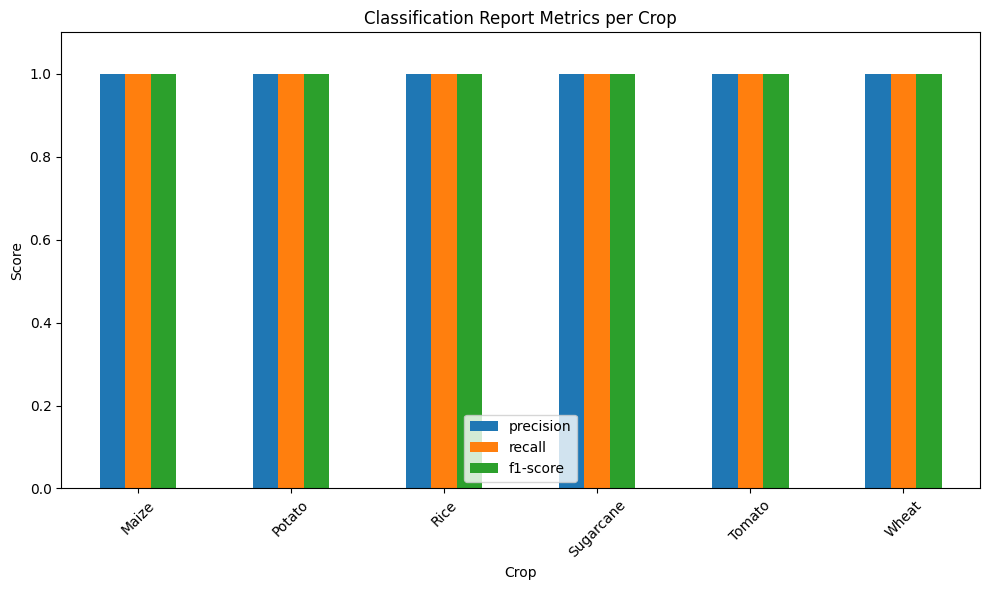

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Get classification report as a dictionary
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)

# Convert to DataFrame for easier plotting, excluding 'accuracy', 'macro avg', 'weighted avg'
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(columns=['support'])

# Filter out aggregate rows for plotting individual class metrics
df_report_classes = df_report.loc[label_encoder.classes_]

# Plotting the classification report
fig, ax = plt.subplots(figsize=(10, 6))
df_report_classes.plot(kind='bar', ax=ax)
ax.set_title('Classification Report Metrics per Crop')
ax.set_ylabel('Score')
ax.set_xlabel('Crop')
ax.set_ylim(0, 1.1) # Set y-limit to clearly show scores between 0 and 1
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Model and label encoder loaded successfully.

Input Conditions:
 Nitrogen  Phosphorus  Potassium  Temperature  Humidity  pH_Value  Rainfall Soil_Type Variety
        0          10          0           20        20       7.5        10                  

Predicted Crop: Tomato
